# InstructPix2Pix 기본 실습 및 LoRA 구현

## 
- **1**: 사전학습된 InstructPix2Pix 모델 실습


---

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import sys
import os
work_dir = '/content/drive/MyDrive/machine_learning_hw10/IP2P_LoRA_FT'
output_dir = os.path.join(work_dir, 'ip2p_results')
os.makedirs(output_dir, exist_ok=True)

Mounted at /content/drive
['/content', '/env/python', '/usr/lib/python312.zip', '/usr/lib/python3.12', '/usr/lib/python3.12/lib-dynload', '', '/usr/local/lib/python3.12/dist-packages', '/usr/lib/python3/dist-packages', '/usr/local/lib/python3.12/dist-packages/IPython/extensions', '/root/.ipython', '/content/drive/MyDrive/machine_learning_hw10/IP2P_LoRA_FT']


In [ ]:
# 라이브러리 설치
!pip install --upgrade diffusers transformers accelerate torch pillow matplotlib -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 899.7/899.7 MB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 594.3/594.3 MB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 88.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 954.8/954.8 kB 61.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.1/193.1 MB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 55.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.6/63.6 MB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.5/267.5 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 288.2/288.2 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.3/322.3 MB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.3/39.3 MB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12

### 라이브러리 Import

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from diffusers import StableDiffusionInstructPix2PixPipeline, EulerAncestralDiscreteScheduler
import PIL
import requests
from io import BytesIO
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display, HTML
import warnings
warnings.filterwarnings('ignore')

---

#   1-1: 기본 InstructPix2Pix 실행

## 목표
사전학습된 InstructPix2Pix 모델을 사용하여 텍스트 지시문 기반 이미지 편집을 수행하고, 다양한 파라미터가 결과에 미치는 영향을 분석합니다.

## InstructPix2Pix란?
- **논문**: [InstructPix2Pix: Learning to Follow Image Editing Instructions](https://arxiv.org/abs/2211.09800)
- **핵심 아이디어**: 자연어 지시문으로 이미지를 편집하는 Diffusion 모델
- **입력**: 원본 이미지 + 편집 지시문 (예: "make it sunset")
- **출력**: 편집된 이미지

## Step 1: 모델 로드

In [ ]:
# InstructPix2Pix 모델 로드
model_id = "timbrooks/instruct-pix2pix"

print("모델 로딩 중... (처음 실행 시 다운로드에 시간이 걸립니다)")
pipe = StableDiffusionInstructPix2PixPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16,
    safety_checker=None
)
pipe.to("cuda")

# Scheduler 설정
pipe.scheduler = EulerAncestralDiscreteScheduler.from_config(pipe.scheduler.config)

print("✅ 모델 로드 완료!")

모델 로딩 중... (처음 실행 시 다운로드에 시간이 걸립니다)


model_index.json:   0%|          | 0.00/616 [00:00<?, ?B/s]

Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/518 [00:00<?, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

unet/diffusion_pytorch_model.safetensors:   0%|          | 0.00/3.44G [00:00<?, ?B/s]

vae/diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

`torch_dtype` is deprecated! Use `dtype` instead!


✅ 모델 로드 완료!


## Step 2: 이미지 로드

테스트할 이미지를 로드합니다. URL에서 이미지 다운로드 또는 로컬 경로에서 이미지 로드

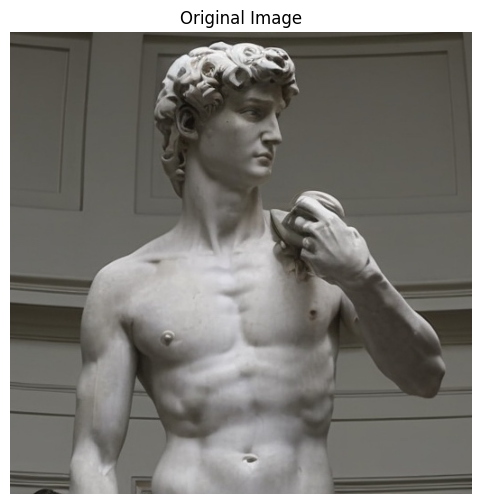

이미지 크기: (512, 512)


In [ ]:
def download_image(url):
    """URL에서 이미지 다운로드"""
    image = PIL.Image.open(requests.get(url, stream=True).raw)
    image = PIL.ImageOps.exif_transpose(image)
    image = image.convert("RGB")
    return image

def load_local_image(path):
    """로컬 경로에서 이미지 로드"""
    image = PIL.Image.open(path)
    image = PIL.ImageOps.exif_transpose(image)
    image = image.convert("RGB")
    return image

## Step 3: 기본 이미지 편집

In [ ]:
# 예제 이미지 다운로드
url = "https://raw.githubusercontent.com/timothybrooks/instruct-pix2pix/main/imgs/example.jpg"
image = download_image(url)

# 이미지 표시
plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.title("Original Image")
plt.axis('off')
plt.show()

print(f"이미지 크기: {image.size}")

편집 중: 'turn him into a cyborg'


  0%|          | 0/20 [00:00<?, ?it/s]

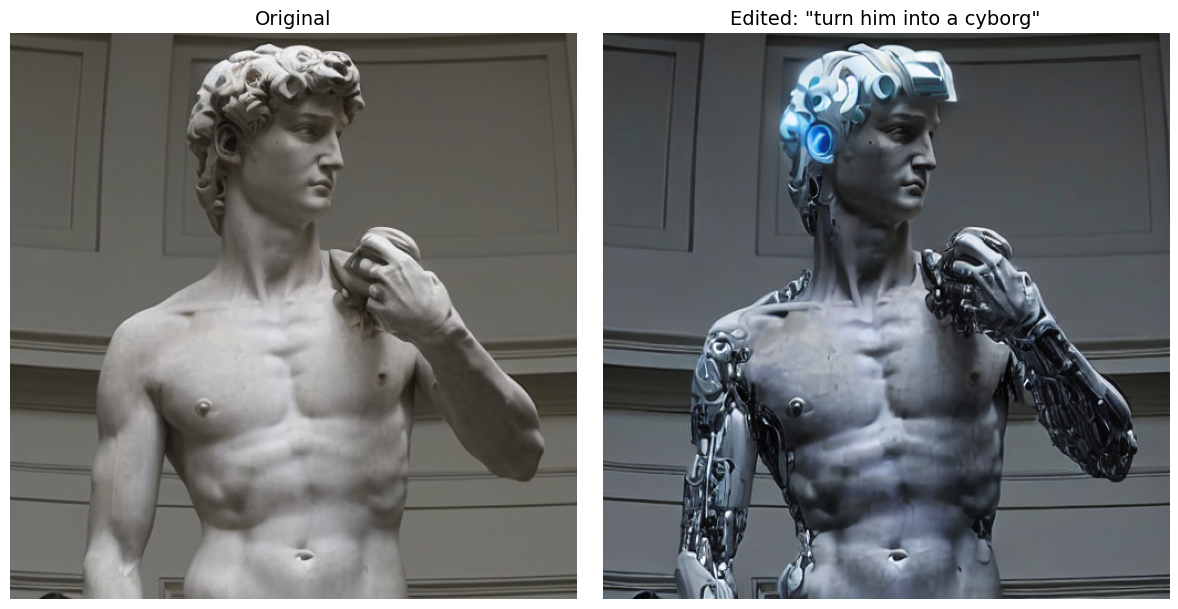

In [ ]:
# 편집 지시문
prompt = "turn him into a cyborg"

# 이미지 생성
print(f"편집 중: '{prompt}'")
images = pipe(
    prompt,
    image=image,
    num_inference_steps=20,  # Diffusion step 수
    image_guidance_scale=1.5  # 원본 이미지 보존 정도
).images

# 결과 비교
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(image)
axes[0].set_title('Original', fontsize=14)
axes[0].axis('off')
axes[1].imshow(images[0])
axes[1].set_title(f'Edited: "{prompt}"', fontsize=14)
axes[1].axis('off')
plt.tight_layout()
plt.show()

---

##  1 실습: 파라미터 실험

### 실습 1: 입력 이미지 및 프롬프트 실험

****: 3개의 서로 다른 이미지와 프롬프트로 편집 결과를 비교하세요.


In [ ]:
# ===== 이미지 1 =====
# 방법 1: URL 사용
image_1_url = "https://example.com/image1.jpg"
image_1 = download_image(image_1_url)

# 방법 2: 드라이브에서 로드
# image_1_path = "/content/drive/MyDrive/machine_learning_hw10/IP2P_LoRA_FT/my_image1.jpg"
# image_1 = load_local_image(image_1_path)

prompt_1 = "make it a watercolor painting"  # 이미지 1의 편집 지시


# ===== 이미지 2 =====
image_2_url = "https://example.com/image2.jpg"
image_2 = download_image(image_2_url)

# image_2_path = "/content/drive/MyDrive/machine_learning_hw10/IP2P_LoRA_FT/my_image2.jpg"
# image_2 = load_local_image(image_2_path)

prompt_2 = "add snow"  # 이미지 2의 편집 지시


# ===== 이미지 3 =====
image_3_url = "https://example.com/image3.jpg"
image_3 = download_image(image_3_url)

# image_3_path = "/content/drive/MyDrive/machine_learning_hw10/IP2P_LoRA_FT/my_image3.jpg"
# image_3 = load_local_image(image_3_path)

prompt_3 = "make it nighttime"  # 이미지 3의 편집 지시


# ===== 편집 수행 =====
image_prompt_pairs = [
    (image_1, prompt_1),
    (image_2, prompt_2),
    (image_3, prompt_3),
]

results = []

for i, (img, prompt) in enumerate(image_prompt_pairs, 1):
    print(f"\n[{i}/3] 편집 중: '{prompt}'")
    edited_image = pipe(
        prompt,
        image=img,
        num_inference_steps=20,
        image_guidance_scale=1.5
    ).images[0]
    results.append((img, prompt, edited_image))


# ===== 결과 시각화 =====
n_pairs = len(results)
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for idx, (original, prompt, edited) in enumerate(results):
    # Original images
    axes[0, idx].imshow(original)
    axes[0, idx].set_title(f'Input {idx+1}', fontsize=12, fontweight='bold')
    axes[0, idx].axis('off')

    # Edited images
    axes[1, idx].imshow(edited)
    axes[1, idx].set_title(f'"{prompt}"', fontsize=10, wrap=True)
    axes[1, idx].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(output_dir, '01_my_edits.png'), dpi=150, bbox_inches='tight')
plt.show()

---

### 실습 2: `num_inference_steps` 영향 분석

**배경지식**:
- Diffusion 모델은 noise를 점진적으로 제거하며 이미지를 생성합니다.
- `num_inference_steps`는 이 denoising 과정의 반복 횟수입니다.
- 많을수록: 품질 ↑, 시간 ↑
- 적을수록: 품질 ↓, 시간 ↓

**과제**: 10, 20, 50 steps로 실험하고 품질과 시간을 비교하세요.

In [ ]:
import time

prompt = "turn him into a cyborg"
steps_list = [10, 20, 50]
results_steps = []

for steps in steps_list:
    print(f"\nInference Steps: {steps}")

    # 시간 측정
    start_time = time.time()

    edited_image = pipe(
        prompt,
        image=image,
        num_inference_steps=steps,
        image_guidance_scale=1.5
    ).images[0]

    elapsed_time = time.time() - start_time
    print(f"소요 시간: {elapsed_time:.2f}초")

    results_steps.append((steps, edited_image, elapsed_time))

# 결과 시각화
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, (steps, img, elapsed) in enumerate(results_steps):
    axes[idx].imshow(img)
    axes[idx].set_title(f'Steps: {steps}\nTime: {elapsed:.2f}s', fontsize=12)
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(output_dir, '02_steps_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

---

### 실습 3: `image_guidance_scale` 영향 분석

**배경지식**:
- `image_guidance_scale`: 원본 이미지를 얼마나 보존할지 조절
- 낮은 값 (< 1.0): 원본에서 크게 벗어남 (창의적)
- 높은 값 (> 1.5): 원본을 많이 보존 (보수적)


In [ ]:
prompt = "turn him into a cyborg"
guidance_scales = [0.5, 1.0, 1.5, 2.0]
results_guidance = []

for scale in guidance_scales:
    print(f"\nImage Guidance Scale: {scale}")

    edited_image = pipe(
        prompt,
        image=image,
        num_inference_steps=20,
        image_guidance_scale=scale
    ).images[0]

    results_guidance.append((scale, edited_image))

# 결과 시각화 (원본 포함)
fig, axes = plt.subplots(1, 5, figsize=(18, 4))

# 원본 이미지
axes[0].imshow(image)
axes[0].set_title('Original', fontsize=12)
axes[0].axis('off')

# 편집된 이미지들
for idx, (scale, img) in enumerate(results_guidance):
    axes[idx + 1].imshow(img)
    axes[idx + 1].set_title(f'Guidance: {scale}', fontsize=12)
    axes[idx + 1].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(output_dir, '03_guidance_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()